# Import libraries

In [305]:
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

# Load data

## OpenAQ

In [306]:
LOAD_OPENAQ_PATH = Path("../data/data.parquet")
data = pd.read_parquet(LOAD_OPENAQ_PATH)
print("\nShape of data:", data.shape)
data.head()


Shape of data: (9089, 32)


,index,value,coordinates,period.label,period.interval,period.datetime_from.utc,period.datetime_from.local,period.datetime_to.utc,period.datetime_to.local,parameter.id,...,coverage.expected_count,coverage.expected_interval,coverage.observed_count,coverage.observed_interval,coverage.percent_complete,coverage.percent_coverage,coverage.datetime_from.utc,coverage.datetime_from.local,coverage.datetime_to.utc,coverage.datetime_to.local
0,0,64.5,None,1hour,01:00:00,2024-12-31T23:00:00Z,2025-01-01T00:00:00+01:00,2025-01-01T00:00:00Z,2025-01-01T01:00:00+01:00,2,...,1,01:00:00,1,01:00:00,100.0,100.0,2024-12-31T23:00:00Z,2025-01-01T00:00:00+01:00,2025-01-01T00:00:00Z,2025-01-01T01:00:00+01:00
1,1,476.0,None,1hour,01:00:00,2025-01-01T00:00:00Z,2025-01-01T01:00:00+01:00,2025-01-01T01:00:00Z,2025-01-01T02:00:00+01:00,2,...,1,01:00:00,1,01:00:00,100.0,100.0,2025-01-01T00:00:00Z,2025-01-01T01:00:00+01:00,2025-01-01T01:00:00Z,2025-01-01T02:00:00+01:00
2,2,475.0,None,1hour,01:00:00,2025-01-01T01:00:00Z,2025-01-01T02:00:00+01:00,2025-01-01T02:00:00Z,2025-01-01T03:00:00+01:00,2,...,1,01:00:00,1,01:00:00,100.0,100.0,2025-01-01T01:00:00Z,2025-01-01T02:00:00+01:00,2025-01-01T02:00:00Z,2025-01-01T03:00:00+01:00
3,3,361.0,None,1hour,01:00:00,2025-01-01T02:00:00Z,2025-01-01T03:00:00+01:00,2025-01-01T03:00:00Z,2025-01-01T04:00:00+01:00,2,...,1,01:00:00,1,01:00:00,100.0,100.0,2025-01-01T02:00:00Z,2025-01-01T03:00:00+01:00,2025-01-01T03:00:00Z,2025-01-01T04:00:00+01:00
4,4,310.0,None,1hour,01:00:00,2025-01-01T03:00:00Z,2025-01-01T04:00:00+01:00,2025-01-01T04:00:00Z,2025-01-01T05:00:00+01:00,2,...,1,01:00:00,1,01:00:00,100.0,100.0,2025-01-01T03:00:00Z,2025-01-01T04:00:00+01:00,2025-01-01T04:00:00Z,2025-01-01T05:00:00+01:00


In [307]:
df_aq = data.pivot(
    columns="parameter.name",
    index="period.datetime_from.local",
    values="value"
).reset_index().copy()

In [308]:
df_aq = df_aq.rename(columns={
    "period.datetime_from.local": "timestamp",
})

In [309]:
df_aq = df_aq.loc[:, ["timestamp", "pm25"]]

In [310]:
df_aq["timestamp"] = pd.to_datetime(df_aq["timestamp"], utc=True)
df_aq["timestamp"]

0      2024-12-31 23:00:00+00:00
1      2025-01-01 00:00:00+00:00
2      2025-01-01 01:00:00+00:00
3      2025-01-01 02:00:00+00:00
4      2025-01-01 03:00:00+00:00
                  ...           
9084   2026-02-28 18:00:00+00:00
9085   2026-02-28 19:00:00+00:00
9086   2026-02-28 20:00:00+00:00
9087   2026-02-28 21:00:00+00:00
9088   2026-02-28 22:00:00+00:00
Name: timestamp, Length: 9089, dtype: datetime64[ns, UTC]

In [311]:
tz_info = pd.to_datetime(df_aq['timestamp'][0]).tzinfo
tz_info

datetime.timezone.utc

## Open Weather

In [312]:
LOAD_WEATHER_PATH = Path("../data/weather.parquet")
wdata = pd.read_parquet(LOAD_WEATHER_PATH)
print("\nShape of data:", wdata.shape)
wdata.head()


Shape of data: (49, 16)


,index,dt,sunrise,sunset,temp,feels_like,pressure,humidity,dew_point,clouds,wind_speed,wind_deg,weather,wind_gust,rain,snow
0,0,1767225600,1767251047,1767281399,268.18,262.74,1022,76,265.01,57,4.03,255,"[{'description': 'broken clouds', 'icon': '04n...",NaN,None,None
1,1,1767229200,1767251047,1767281399,267.03,267.03,1021,78,264.18,40,0.45,279,"[{'description': 'scattered clouds', 'icon': '...",0.45,None,None
2,2,1767232800,1767251047,1767281399,265.95,265.95,1021,83,263.82,26,0.45,220,"[{'description': 'scattered clouds', 'icon': '...",0.45,None,None
3,3,1767236400,1767251047,1767281399,265.19,259.74,1020,84,263.21,17,3.32,256,"[{'description': 'few clouds', 'icon': '02n', ...",NaN,None,None
4,4,1767240000,1767251047,1767281399,265.38,265.38,1019,85,263.53,23,0.45,138,"[{'description': 'few clouds', 'icon': '02n', ...",0.45,None,None


In [313]:
wdata["timestamp"] = wdata["dt"].apply(
    lambda x: dt.datetime.fromtimestamp(x, tz=tz_info)
)

In [314]:
wdata = wdata[[
    "temp", "feels_like", "pressure", "wind_gust", "timestamp"
]]

## Merge

In [315]:
df = pd.merge(
    wdata,
    df_aq,
    how="left",
).reset_index()
df.head()

,index,temp,feels_like,pressure,wind_gust,timestamp,pm25
0,0,268.18,262.74,1022,NaN,2026-01-01 00:00:00+00:00,616.0
1,1,267.03,267.03,1021,0.45,2026-01-01 01:00:00+00:00,267.0
2,2,265.95,265.95,1021,0.45,2026-01-01 02:00:00+00:00,180.0
3,3,265.19,259.74,1020,NaN,2026-01-01 03:00:00+00:00,102.0
4,4,265.38,265.38,1019,0.45,2026-01-01 04:00:00+00:00,98.2


In [316]:
df = df.fillna(0)

# Feature engineering

## Date features

In [317]:
def is_weekend(day_of_week: int) -> int:
    match day_of_week:
        case 0 | 7:
            return 1
        case _:
            return 0
        
def is_new_years(timestamp) -> bool:
    if ((timestamp.month == 12 and timestamp.day_of_week == 31) 
        or 
        (timestamp.month == 1 and timestamp.day_of_week == 1)):
        return True
    else:
        return False

In [318]:
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.day_of_week
df['hour_of_day'] = df['timestamp'].dt.hour
df['is_weekend'] = df['day_of_week'].apply(lambda day: is_weekend(day))
df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['month_sin'] = np.sin(2* np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2* np.pi * df['month'] / 12)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['is_new_year'] = df["timestamp"].apply(lambda x: is_new_years(x))

## Rolling & lag

In [343]:
target = 'pm25'
lag_periods = [3, 6]
rolling_window = [3]

In [344]:
for window in rolling_window:
    df[f'rolling_{target}_{str(window)}'] = df[target].rolling(window=window).mean()

for period in lag_periods:
    df[f'lag_{target}_{str(period)}'] = df[target].shift(periods=period)

## Shifted target

In [345]:
df['target'] = df[target].shift(-3)

# Create data splits

In [346]:
df = df.dropna()

In [347]:
train_idx = int(np.ceil(len(df) * .9))
print(train_idx)

28


In [348]:
train_df = df.loc[:train_idx, :]
test_df = df.loc[train_idx:, :]

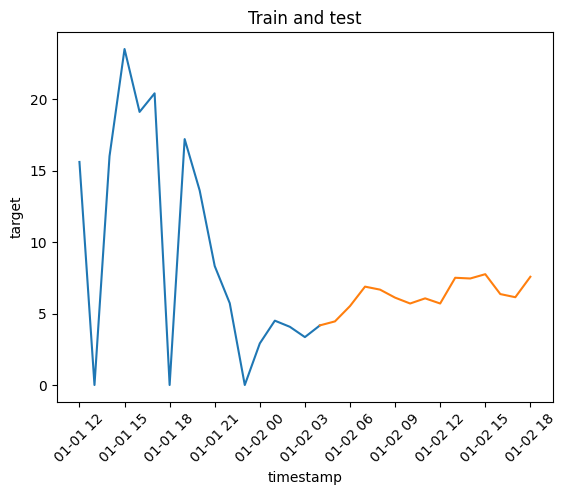

In [349]:
sns.lineplot(train_df, x="timestamp", y="target")
sns.lineplot(test_df, x="timestamp", y="target")
plt.title("Train and test")
plt.xticks(rotation=45)
plt.show()

In [350]:
X_train = train_df.drop(['timestamp', 'target'], axis=1)
y_train = train_df.loc[:, 'target']

X_test = test_df.drop(['timestamp', 'target'], axis=1)
y_test = test_df.loc[:, 'target']

train_timestamp = train_df.loc[:, 'timestamp']
test_timestamp = test_df.loc[:, 'timestamp']

# Train model

## Baseline (Ridge)

In [351]:
clf = Ridge(alpha=1.0)
clf.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [352]:
y_hat = clf.predict(X_test)
mae = mean_absolute_error(y_test, y_hat)
r2 = r2_score(y_test, y_hat)

print("MAE", mae)
print("r2", r2)

MAE 4.20065067681343
r2 -25.578270141139505


In [353]:
test_timestamp

28   2026-01-02 04:00:00+00:00
29   2026-01-02 05:00:00+00:00
30   2026-01-02 06:00:00+00:00
31   2026-01-02 07:00:00+00:00
32   2026-01-02 08:00:00+00:00
33   2026-01-02 09:00:00+00:00
34   2026-01-02 10:00:00+00:00
35   2026-01-02 11:00:00+00:00
36   2026-01-02 12:00:00+00:00
37   2026-01-02 13:00:00+00:00
38   2026-01-02 14:00:00+00:00
39   2026-01-02 15:00:00+00:00
40   2026-01-02 16:00:00+00:00
41   2026-01-02 17:00:00+00:00
42   2026-01-02 18:00:00+00:00
Name: timestamp, dtype: datetime64[ns, UTC]

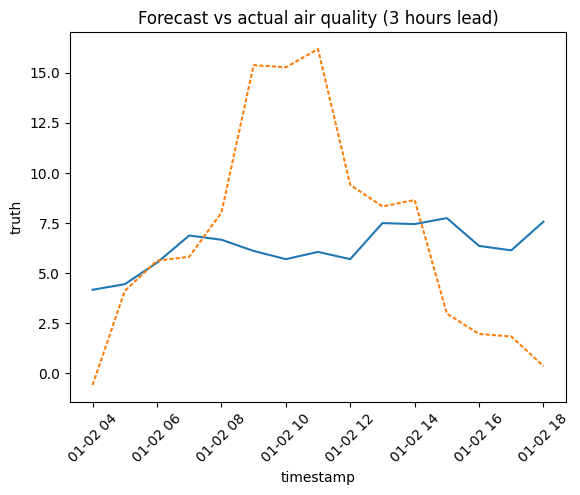

In [354]:
y_hat_df = pd.DataFrame(
    data={
        "timestamp": test_timestamp,
        "truth": y_test,
        "pred": y_hat
    }
)

sns.lineplot(y_hat_df, x="timestamp", y="truth")
sns.lineplot(y_hat_df, x="timestamp", y="pred", dashes=[2, 1])

plt.title("Forecast vs actual air quality (3 hours lead)")
plt.xticks(rotation=45)
plt.show()

In [355]:
y_hat_df.head()

,timestamp,truth,pred
28,2026-01-02 04:00:00+00:00,4.17,-0.587622
29,2026-01-02 05:00:00+00:00,4.45,4.112812
30,2026-01-02 06:00:00+00:00,5.52,5.625544
31,2026-01-02 07:00:00+00:00,6.88,5.817679
32,2026-01-02 08:00:00+00:00,6.67,8.018404


In [356]:
pd.DataFrame(data={
    "coef": clf.coef_,
    "feature": clf.feature_names_in_
}) \
    .sort_values('coef', ascending=False) \
    .reset_index() \
    .drop('index', axis=1)

,coef,feature
0,5.446316e+00,pressure
1,6.836048e-01,hour_sin
2,3.452162e-01,temp
3,2.961630e-01,index
4,5.761535e-02,hour_of_day
5,9.939486e-03,day_of_week
6,1.947500e-28,month_sin
7,0.000000e+00,is_new_year
8,0.000000e+00,month
9,0.000000e+00,is_weekend


In [357]:
df.groupby('month').agg({
    'target': 'mean'
})

,target
month,
1,8.009677


# Final remarks
At the end of this experiment, we observe the following:
- Removing lag and rolling features makes model **useless** (worth than guessing)
- As such, current features (temperature, humidity and temporal features) **do not** have significant explanatory power.
- Further feature engineering is required. Likely candidates:
    - Wind
    - Pressure

# Prophet

In [358]:
from prophet import Prophet

In [359]:
prophet_df = df.loc[:, ["timestamp", "pm25"]]
prophet_df = prophet_df.rename(columns={"timestamp":"ds", "pm25":"y"})

In [360]:
prophet_df['ds'] = prophet_df['ds'].dt.tz_localize(None)

In [361]:
m = Prophet()
m.fit(prophet_df)

23:02:16 - cmdstanpy - INFO - Chain [1] start processing
23:02:16 - cmdstanpy - INFO - Chain [1] done processing


In [362]:
# Python
future = m.make_future_dataframe(periods=48)
future.tail()

,ds
74,2026-02-15 18:00:00
75,2026-02-16 18:00:00
76,2026-02-17 18:00:00
77,2026-02-18 18:00:00
78,2026-02-19 18:00:00


In [363]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
74,2026-02-15 18:00:00,-229.724448,-237.227061,-222.348305
75,2026-02-16 18:00:00,-235.051319,-242.726793,-227.955933
76,2026-02-17 18:00:00,-240.378190,-247.702342,-233.253330
77,2026-02-18 18:00:00,-245.705061,-253.625109,-238.568456
78,2026-02-19 18:00:00,-251.031931,-258.562301,-243.439805


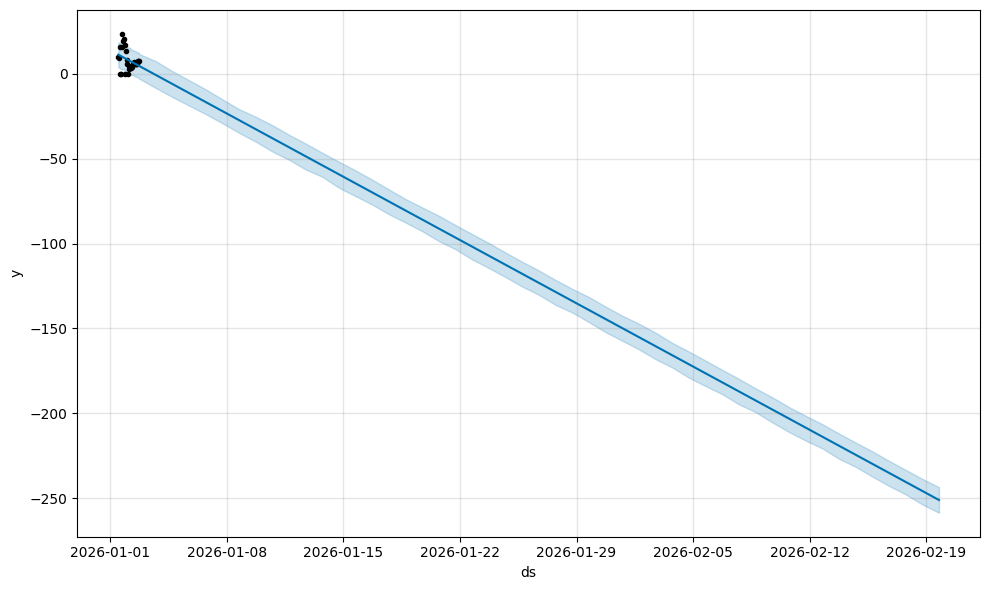

In [364]:
fig1 = m.plot(forecast)

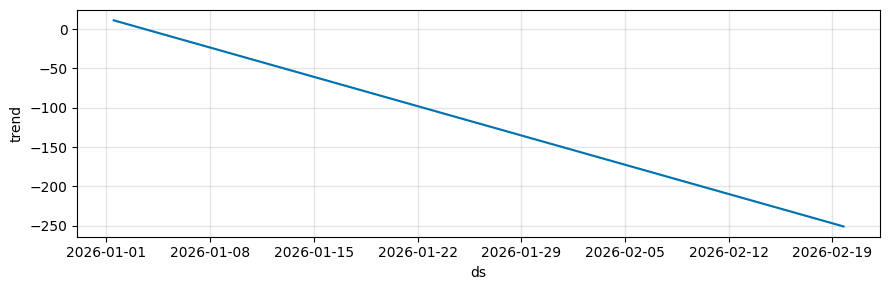

In [365]:
fig2 = m.plot_components(forecast)

In [366]:
df.describe()

,index,temp,feels_like,pressure,wind_gust,pm25,year,month,day_of_week,hour_of_day,...,hour_sin,hour_cos,month_sin,month_cos,day_sin,day_cos,rolling_pm25_3,lag_pm25_3,lag_pm25_6,target
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.0,31.0,31.000000,31.000000,...,31.000000,31.000000,31.0,3.100000e+01,31.000000,3.100000e+01,31.000000,31.000000,31.000000,31.000000
mean,27.000000,274.529032,270.901935,1005.870968,6.605161,7.988065,2026.0,1.0,3.612903,12.290323,...,-0.138641,-0.138641,0.5,8.660254e-01,-0.097974,-9.009689e-01,8.121290,8.996774,12.946452,8.009677
std,9.092121,0.985770,1.789613,2.232218,1.917356,6.197950,0.0,0.0,0.495138,6.440463,...,0.704844,0.704844,0.0,3.385725e-16,0.429664,3.861917e-16,4.533197,7.289759,13.489002,6.024432
min,12.000000,272.840000,267.430000,1003.000000,3.580000,0.000000,2026.0,1.0,3.000000,0.000000,...,-1.000000,-1.000000,0.5,8.660254e-01,-0.433884,-9.009689e-01,2.470000,0.000000,0.000000,0.000000
25%,19.500000,274.000000,269.775000,1004.000000,5.360000,4.310000,2026.0,1.0,3.000000,7.500000,...,-0.786566,-0.786566,0.5,8.660254e-01,-0.433884,-9.009689e-01,4.956667,4.310000,4.310000,4.475000
50%,27.000000,274.470000,270.660000,1005.000000,6.260000,6.110000,2026.0,1.0,4.000000,13.000000,...,-0.258819,-0.258819,0.5,8.660254e-01,-0.433884,-9.009689e-01,6.466667,6.110000,8.320000,6.140000
75%,34.500000,274.850000,271.760000,1008.000000,7.825000,9.700000,2026.0,1.0,4.000000,17.000000,...,0.500000,0.500000,0.5,8.660254e-01,0.433884,-9.009689e-01,10.400000,14.600000,17.800000,8.035000
max,42.000000,277.220000,275.670000,1011.000000,11.180000,23.500000,2026.0,1.0,4.000000,23.000000,...,1.000000,1.000000,0.5,8.660254e-01,0.433884,-9.009689e-01,21.000000,27.100000,55.000000,23.500000
